# Population tandem-repeat diversity from SniffCell harmonized variants

This notebook combines one `harmonized_variants.tsv` per sample, retains `variant_class == "TR"`, and summarizes tandem-repeat call diversity across a cohort.

## tl;dr

The first executed version is validated on one coherent SMaHT brain run containing 87 sample files. It found **165 TR calls across 54 exact sites**; 24 sites occurred in at least two samples and 9 occurred in at least five. The live headline table below recomputes these numbers for whichever glob is configured.

**Interpretation boundary:** these are *differential TR calls between the two SniffCell groups in each sample*. A missing row is not proof of a reference allele or adequate coverage. Therefore, `call_prevalence_pct` is the percentage of input sample files containing a call at a site—not a population allele frequency.

In [2]:
from glob import glob
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Replace this with your population glob. Keep all files from one comparable
# SniffCell workflow/catalog when you want exact-coordinate site recurrence.
TSV_GLOB = "/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/brains/results_new_catalog_sniffcell094/same_catalog_run/*/deconv/deconv_requested_group_splits/discover/new_catalog_sniffcell094_same_catalog_run_all/harmonized_variants.tsv"

tsv_files = sorted(glob(TSV_GLOB, recursive=True))
print(f"Found {len(tsv_files):,} harmonized TSV files")
print("First file:", tsv_files[0] if tsv_files else "<none>")

if not tsv_files:
    raise FileNotFoundError(
        "The glob matched no files. Update TSV_GLOB. Use **/*harmonized_variants.tsv "
        "with recursive=True when files occur at variable directory depths."
    )

Found 87 harmonized TSV files
First file: /stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/brains/results_new_catalog_sniffcell094/same_catalog_run/SMHT001-3AK-001A2-M42-B001-broad/deconv/deconv_requested_group_splits/discover/new_catalog_sniffcell094_same_catalog_run_all/harmonized_variants.tsv


## Context & Methods

### Key assumptions

- One input file represents one sample. The sample ID is inferred as the directory immediately before `deconv`.
- A population TR **site** is defined by exact `(chrom, start, end)` coordinates. This is appropriate when all samples used the same catalog and reference build.
- Multiple rows for the same sample and exact site are preserved as calls but collapsed to one sample-site observation for prevalence.
- `change_size_bp` measures the SniffCell change-group versus baseline-group length difference. It is not an absolute diploid genotype.
- No category, subtype, recurrence, or change-size filter is applied by default.

In [3]:
REQUIRED_COLUMNS = {
    "chrom", "start", "end", "variant_class", "variant_id",
    "variant_subtype", "category", "change_size_bp",
    "group_a_alt_reads", "group_b_alt_reads",
}
READ_COLUMNS = sorted(REQUIRED_COLUMNS)
# Outputs are written beside the notebook when executed with nbconvert/Jupyter.
OUTPUT_DIR = Path("population_tr_diversity_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def infer_sample_id(path_text: str) -> str:
    # Infer sample ID from .../<sample_id>/deconv/.../harmonized_variants.tsv.
    path = Path(path_text)
    parts = path.parts
    deconv_positions = [i for i, part in enumerate(parts) if part == "deconv"]
    if deconv_positions and deconv_positions[-1] > 0:
        return parts[deconv_positions[-1] - 1]
    return path.parent.name


def joined_unique(values) -> str:
    clean = sorted({str(value) for value in values if pd.notna(value) and str(value).strip()})
    return ";".join(clean)


def shannon_entropy(values) -> float:
    counts = pd.Series(values).dropna().value_counts()
    if counts.empty:
        return np.nan
    probabilities = counts.to_numpy(dtype=float) / counts.sum()
    return float(-(probabilities * np.log2(probabilities)).sum())


def chrom_sort_value(chrom: str) -> tuple[int, str]:
    text = str(chrom)
    bare = text[3:] if text.lower().startswith("chr") else text
    ranks = {str(i): i for i in range(1, 23)} | {"X": 23, "Y": 24, "M": 25, "MT": 25}
    return ranks.get(bare.upper(), 99), text

## Data

### 1. Load only analysis columns and preserve file-level provenance

In [4]:
frames = []
file_rows = []

for path_text in tsv_files:
    path = Path(path_text)
    sample_id = infer_sample_id(path_text)
    try:
        header = list(pd.read_csv(path, sep="\t", nrows=0).columns)
        missing = sorted(REQUIRED_COLUMNS - set(header))
        if missing:
            file_rows.append({
                "sample_id": sample_id, "source_path": str(path), "status": "schema_error",
                "n_rows": np.nan, "n_tr_rows": np.nan, "missing_columns": ";".join(missing),
            })
            continue
        frame = pd.read_csv(path, sep="\t", usecols=READ_COLUMNS, low_memory=False)
        frame["sample_id"] = sample_id
        frame["source_path"] = str(path)
        frames.append(frame)
        file_rows.append({
            "sample_id": sample_id, "source_path": str(path), "status": "loaded",
            "n_rows": len(frame),
            "n_tr_rows": int(frame["variant_class"].astype(str).str.upper().eq("TR").sum()),
            "missing_columns": "",
        })
    except Exception as exc:
        file_rows.append({
            "sample_id": sample_id, "source_path": str(path), "status": "read_error",
            "n_rows": np.nan, "n_tr_rows": np.nan, "missing_columns": "",
            "error": f"{type(exc).__name__}: {exc}",
        })

input_manifest = pd.DataFrame(file_rows)
loaded_manifest = input_manifest[input_manifest["status"].eq("loaded")].copy()
if not frames:
    raise RuntimeError("No valid harmonized TSV files were loaded; inspect input_manifest.")

all_variants = pd.concat(frames, ignore_index=True)
tr_calls = all_variants[
    all_variants["variant_class"].astype(str).str.strip().str.upper().eq("TR")
].copy()

for column in ["start", "end", "change_size_bp", "group_a_alt_reads", "group_b_alt_reads"]:
    tr_calls[column] = pd.to_numeric(tr_calls[column], errors="coerce")

tr_calls["site_key"] = (
    tr_calls["chrom"].astype(str) + ":" +
    tr_calls["start"].astype("Int64").astype(str) + "-" +
    tr_calls["end"].astype("Int64").astype(str)
)
tr_calls["total_alt_reads"] = (
    tr_calls["group_a_alt_reads"].fillna(0) + tr_calls["group_b_alt_reads"].fillna(0)
)

print(f"Loaded {len(loaded_manifest):,}/{len(input_manifest):,} files")
print(f"All variant rows: {len(all_variants):,}")
print(f"TR rows: {len(tr_calls):,}")
display(input_manifest.head(5))

Loaded 87/87 files
All variant rows: 36,388
TR rows: 165


,sample_id,source_path,status,n_rows,n_tr_rows,missing_columns
0,SMHT001-3AK-001A2-M42-B001-broad,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,loaded,92,2,
1,SMHT001-3AL-001B2-M42-B001-broad,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,loaded,4,0,
2,SMHT001-3AM-001D2-M42-D001-uwsc,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,loaded,849,1,
3,SMHT001-3AM-002A2-M42-B004-uwsc,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,loaded,25,0,
4,SMHT001-3AN-001B1-M42-B001-broad,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,loaded,11,0,


### 2. Validate schema, sample grain, coordinates, and call fields

In [5]:
duplicate_sample_ids = int(loaded_manifest["sample_id"].duplicated(keep=False).sum())
duplicate_sample_site_rows = int(tr_calls.duplicated(["sample_id", "site_key"], keep=False).sum())
invalid_coordinates = int(
    (tr_calls["start"].isna() | tr_calls["end"].isna() | (tr_calls["end"] <= tr_calls["start"])).sum()
)
missing_site_fields = int(
    tr_calls[["chrom", "start", "end", "variant_id", "variant_subtype"]].isna().any(axis=1).sum()
)
nonpositive_change_sizes = int((tr_calls["change_size_bp"].fillna(0) <= 0).sum())
unexpected_categories = int(
    (~tr_calls["category"].astype(str).isin(["group_a_only", "group_b_only", "shared", "unknown"])).sum()
)

quality_checks = pd.DataFrame([
    {"check": "input files matched", "value": len(input_manifest), "expected": "> 0", "status": "PASS" if len(input_manifest) else "FAIL"},
    {"check": "files loaded", "value": len(loaded_manifest), "expected": len(input_manifest), "status": "PASS" if len(loaded_manifest) == len(input_manifest) else "WARN"},
    {"check": "duplicate inferred sample IDs (rows in manifest)", "value": duplicate_sample_ids, "expected": 0, "status": "PASS" if duplicate_sample_ids == 0 else "WARN"},
    {"check": "duplicate sample-site TR rows", "value": duplicate_sample_site_rows, "expected": 0, "status": "PASS" if duplicate_sample_site_rows == 0 else "WARN"},
    {"check": "TR rows with missing site fields", "value": missing_site_fields, "expected": 0, "status": "PASS" if missing_site_fields == 0 else "FAIL"},
    {"check": "TR rows with invalid coordinates", "value": invalid_coordinates, "expected": 0, "status": "PASS" if invalid_coordinates == 0 else "FAIL"},
    {"check": "TR rows with non-positive/missing change_size_bp", "value": nonpositive_change_sizes, "expected": 0, "status": "PASS" if nonpositive_change_sizes == 0 else "WARN"},
    {"check": "TR rows with unexpected category", "value": unexpected_categories, "expected": 0, "status": "PASS" if unexpected_categories == 0 else "WARN"},
])
display(quality_checks)

if (quality_checks["status"] == "FAIL").any():
    raise ValueError("Blocking data-quality check failed; inspect quality_checks before interpreting results.")

,check,value,expected,status
0,input files matched,87,> 0,PASS
1,files loaded,87,87,PASS
2,duplicate inferred sample IDs (rows in manifest),0,0,PASS
3,duplicate sample-site TR rows,0,0,PASS
4,TR rows with missing site fields,0,0,PASS
5,TR rows with invalid coordinates,0,0,PASS
6,TR rows with non-positive/missing change_size_bp,0,0,PASS
7,TR rows with unexpected category,0,0,PASS


## Results

### 3. Headline population numbers

`unique_tr_sites` uses exact coordinates. `samples_with_any_tr` includes only samples with at least one TR call, while the prevalence denominator remains every successfully loaded sample file, including zero-call samples.

In [6]:
n_samples = int(loaded_manifest["sample_id"].nunique())

sample_site = (
    tr_calls.groupby(["sample_id", "site_key", "chrom", "start", "end"], dropna=False)
    .agg(
        n_calls=("variant_id", "size"),
        variant_ids=("variant_id", joined_unique),
        variant_subtypes=("variant_subtype", joined_unique),
        categories=("category", joined_unique),
        change_size_bp=("change_size_bp", "median"),
        max_change_size_bp=("change_size_bp", "max"),
        total_alt_reads=("total_alt_reads", "max"),
    )
    .reset_index()
)

site_recurrence = sample_site.groupby("site_key")["sample_id"].nunique()
headline_metrics = pd.Series({
    "input_files": len(input_manifest),
    "loaded_files": len(loaded_manifest),
    "unique_samples": n_samples,
    "samples_with_any_tr": int(tr_calls["sample_id"].nunique()),
    "all_variant_rows": len(all_variants),
    "total_tr_calls": len(tr_calls),
    "unique_sample_site_pairs": len(sample_site),
    "unique_tr_sites": int(sample_site["site_key"].nunique()),
    "unique_tr_subtypes": int(tr_calls["variant_subtype"].nunique(dropna=True)),
    "unique_change_sizes_bp": int(tr_calls["change_size_bp"].nunique(dropna=True)),
    "singleton_sites": int((site_recurrence == 1).sum()),
    "recurrent_sites_ge_2_samples": int((site_recurrence >= 2).sum()),
    "recurrent_sites_ge_5_samples": int((site_recurrence >= 5).sum()),
    "maximum_samples_at_one_site": int(site_recurrence.max()) if len(site_recurrence) else 0,
}, name="value").rename_axis("metric").reset_index()

display(headline_metrics)

,metric,value
0,input_files,87
1,loaded_files,87
2,unique_samples,87
3,samples_with_any_tr,65
4,all_variant_rows,36388
5,total_tr_calls,165
6,unique_sample_site_pairs,165
7,unique_tr_sites,54
8,unique_tr_subtypes,1
9,unique_change_sizes_bp,153


### 4. TR subtype and direction/category composition

In [7]:
subtype_summary = (
    tr_calls.groupby("variant_subtype", dropna=False)
    .agg(n_calls=("variant_id", "size"), n_samples=("sample_id", "nunique"), n_sites=("site_key", "nunique"))
    .reset_index()
    .sort_values(["n_calls", "variant_subtype"], ascending=[False, True], ignore_index=True)
)
subtype_summary["percent_of_tr_calls"] = 100 * subtype_summary["n_calls"] / max(len(tr_calls), 1)

category_summary = (
    tr_calls.groupby("category", dropna=False)
    .agg(n_calls=("variant_id", "size"), n_samples=("sample_id", "nunique"), n_sites=("site_key", "nunique"))
    .reset_index()
    .sort_values(["n_calls", "category"], ascending=[False, True], ignore_index=True)
)
category_summary["percent_of_tr_calls"] = 100 * category_summary["n_calls"] / max(len(tr_calls), 1)

size_bins = [0, 100, 250, 500, 1_000, 5_000, np.inf]
size_labels = ["1-100", "101-250", "251-500", "501-1,000", "1,001-5,000", ">5,000"]
tr_calls["change_size_bin_bp"] = pd.cut(
    tr_calls["change_size_bp"], bins=size_bins, labels=size_labels, include_lowest=True
)
change_size_summary = (
    tr_calls.groupby("change_size_bin_bp", observed=False)
    .agg(n_calls=("variant_id", "size"), n_samples=("sample_id", "nunique"), n_sites=("site_key", "nunique"))
    .reset_index()
)
change_size_summary["percent_of_tr_calls"] = 100 * change_size_summary["n_calls"] / max(len(tr_calls), 1)

display(Markdown("**TR subtypes**"))
display(subtype_summary)
display(Markdown("**SniffCell group direction/category**"))
display(category_summary)
display(Markdown("**Change-size bins (bp)**"))
display(change_size_summary)

**TR subtypes**

,variant_subtype,n_calls,n_samples,n_sites,percent_of_tr_calls
0,expansion_all,165,65,54,100.0


**SniffCell group direction/category**

,category,n_calls,n_samples,n_sites,percent_of_tr_calls
0,group_b_only,88,50,34,53.333333
1,group_a_only,77,49,29,46.666667


**Change-size bins (bp)**

,change_size_bin_bp,n_calls,n_samples,n_sites,percent_of_tr_calls
0,1-100,15,13,10,9.090909
1,101-250,32,26,17,19.393939
2,251-500,25,21,17,15.151515
3,"501-1,000",32,25,17,19.393939
4,"1,001-5,000",52,41,16,31.515152
5,">5,000",9,9,6,5.454545


### 5. Per-sample TR burden, including zero-call samples

In [8]:
per_sample_called = (
    tr_calls.groupby("sample_id")
    .agg(
        n_tr_calls=("variant_id", "size"),
        n_unique_tr_sites=("site_key", "nunique"),
        n_unique_tr_subtypes=("variant_subtype", "nunique"),
        median_change_size_bp=("change_size_bp", "median"),
        max_change_size_bp=("change_size_bp", "max"),
        median_alt_support_reads=("total_alt_reads", "median"),
        n_group_a_only=("category", lambda x: int((x == "group_a_only").sum())),
        n_group_b_only=("category", lambda x: int((x == "group_b_only").sum())),
    )
    .reset_index()
)

per_sample_summary = (
    loaded_manifest[["sample_id", "source_path"]]
    .drop_duplicates("sample_id")
    .merge(per_sample_called, on="sample_id", how="left", validate="one_to_one")
)
count_columns = ["n_tr_calls", "n_unique_tr_sites", "n_unique_tr_subtypes", "n_group_a_only", "n_group_b_only"]
per_sample_summary[count_columns] = per_sample_summary[count_columns].fillna(0).astype(int)
per_sample_summary = per_sample_summary.sort_values(
    ["n_unique_tr_sites", "n_tr_calls", "sample_id"], ascending=[False, False, True], ignore_index=True
)

display(per_sample_summary.head(20))
display(per_sample_summary["n_tr_calls"].describe().to_frame("TR calls per input sample"))

,sample_id,source_path,n_tr_calls,n_unique_tr_sites,n_unique_tr_subtypes,median_change_size_bp,max_change_size_bp,median_alt_support_reads,n_group_a_only,n_group_b_only
0,SMHT020-3AK-002MC-M81-D001-bcm,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,7,7,1,1027.0,6828.0,7.0,4,3
1,SMHT022-3AL-001C4-M63-D001-nygc,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,6,6,1,461.0,1231.0,5.0,2,4
2,SMHT031-3AK-003C3-M65-D001-bcm,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,6,6,1,499.5,3189.0,9.5,2,4
3,SMHT001-3AO-001B3-M42-D001-uwsc,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,5,5,1,185.0,785.0,4.0,3,2
4,SMHT018-3AK-001B3-F89-D001-bcm,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,5,5,1,522.0,1166.0,6.0,3,2
5,SMHT020-3AL-001MC-M81-D001-bcm,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,5,5,1,551.0,9423.0,4.0,3,2
6,SMHT022-3AO-001B2-M63-D001-nygc,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,5,5,1,674.0,7167.0,4.0,4,1
7,SMHT005-3AN-001A2-M59-B004-uwsc,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,4,4,1,488.0,1756.0,3.5,2,2
8,SMHT018-3AL-002C2-F89-D001-bcm,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,4,4,1,957.5,6455.0,4.0,1,3
9,SMHT020-3AO-004MC-M81-D001-bcm,/stornext/snfs210/fritz/Yilei/SMaHT/sniffcell/...,4,4,1,1080.0,3208.0,4.0,1,3


,TR calls per input sample
count,87.000000
mean,1.896552
std,1.712026
min,0.000000
25%,0.500000
50%,1.000000
75%,3.000000
max,7.000000


### 6. Per-site recurrence and change-size diversity

In [9]:
site_rows = []
for site_key, group in tr_calls.groupby("site_key", sort=False):
    sample_group = sample_site[sample_site["site_key"].eq(site_key)]
    sizes = pd.to_numeric(group["change_size_bp"], errors="coerce").dropna()
    first = group.iloc[0]
    site_rows.append({
        "site_key": site_key,
        "chrom": first["chrom"],
        "start": int(first["start"]),
        "end": int(first["end"]),
        "variant_ids": joined_unique(group["variant_id"]),
        "n_calls": len(group),
        "n_samples": int(sample_group["sample_id"].nunique()),
        "call_prevalence_pct": 100 * sample_group["sample_id"].nunique() / max(n_samples, 1),
        "n_subtypes": int(group["variant_subtype"].nunique(dropna=True)),
        "variant_subtypes": joined_unique(group["variant_subtype"]),
        "categories": joined_unique(group["category"]),
        "n_unique_change_sizes_bp": int(sizes.nunique()),
        "min_change_size_bp": sizes.min() if len(sizes) else np.nan,
        "q1_change_size_bp": sizes.quantile(0.25) if len(sizes) else np.nan,
        "median_change_size_bp": sizes.median() if len(sizes) else np.nan,
        "mean_change_size_bp": sizes.mean() if len(sizes) else np.nan,
        "q3_change_size_bp": sizes.quantile(0.75) if len(sizes) else np.nan,
        "max_change_size_bp": sizes.max() if len(sizes) else np.nan,
        "range_change_size_bp": (sizes.max() - sizes.min()) if len(sizes) else np.nan,
        "change_size_shannon_bits": shannon_entropy(sizes),
        "median_alt_support_reads": group["total_alt_reads"].median(),
        "max_alt_support_reads": group["total_alt_reads"].max(),
    })

per_site_summary = pd.DataFrame(site_rows)
if not per_site_summary.empty:
    per_site_summary[["_chrom_rank", "_chrom_text"]] = pd.DataFrame(
        per_site_summary["chrom"].map(chrom_sort_value).tolist(), index=per_site_summary.index
    )
    per_site_summary = per_site_summary.sort_values(
        ["n_samples", "n_unique_change_sizes_bp", "_chrom_rank", "_chrom_text", "start"],
        ascending=[False, False, True, True, True], ignore_index=True,
    ).drop(columns=["_chrom_rank", "_chrom_text"])

display(per_site_summary.head(25))

,site_key,chrom,start,end,variant_ids,n_calls,n_samples,call_prevalence_pct,n_subtypes,variant_subtypes,...,min_change_size_bp,q1_change_size_bp,median_change_size_bp,mean_change_size_bp,q3_change_size_bp,max_change_size_bp,range_change_size_bp,change_size_shannon_bits,median_alt_support_reads,max_alt_support_reads
0,chr9:66249319-66249834,chr9,66249319,66249834,chr9_66249319_66249834,28,28,32.183908,1,expansion_all,...,281,1228.25,1479.0,1677.428571,1569.25,9423,9142,4.735926,8.0,20
1,chr16:90116644-90118559,chr16,90116644,90118559,chr16_90116644_90118559,17,17,19.540230,1,expansion_all,...,64,147.00,922.0,1223.647059,1509.00,4906,4842,3.969816,7.0,32
2,chr13:77703851-77705128,chr13,77703851,77705128,chr13_77703851_77705128,15,15,17.241379,1,expansion_all,...,81,113.00,208.0,382.933333,621.00,1108,1027,3.906891,3.0,5
3,chr16:21834701-21837624,chr16,21834701,21837624,chr16_21834701_21837624,10,10,11.494253,1,expansion_all,...,140,257.50,592.0,449.600000,596.75,613,473,3.321928,7.0,13
4,chr9:64462195-64462443,chr9,64462195,64462443,chr9_64462195_64462443,8,8,9.195402,1,expansion_all,...,400,478.25,514.0,491.375000,515.25,517,117,2.750000,4.0,7
5,chr20:30676078-30676308,chr20,30676078,30676308,chr20_30676078_30676308,7,7,8.045977,1,expansion_all,...,144,147.00,149.0,4052.285714,3659.00,20461,20317,2.807355,4.0,6
6,chr19:33757354-33757634,chr19,33757354,33757634,chr19_33757354_33757634,5,5,5.747126,1,expansion_all,...,76,99.00,151.0,222.400000,199.00,587,511,2.321928,5.0,10
7,chr22:21308557-21309542,chr22,21308557,21309542,chr22_21308557_21309542,5,5,5.747126,1,expansion_all,...,324,328.00,431.0,505.200000,674.00,769,445,2.321928,4.0,7
8,chrX:56780941-56783155,chrX,56780941,56783155,chrX_56780941_56783155,5,5,5.747126,1,expansion_all,...,1008,1027.00,1027.0,1025.600000,1030.00,1036,28,1.921928,4.0,9
9,chr1:602071-602394,chr1,602071,602394,chr1_602071_602394,4,4,4.597701,1,expansion_all,...,279,279.00,400.5,417.000000,538.50,588,309,1.500000,4.5,7


In [11]:
per_site_summary.columns

Index(['site_key', 'chrom', 'start', 'end', 'variant_ids', 'n_calls',
       'n_samples', 'call_prevalence_pct', 'n_subtypes', 'variant_subtypes',
       'categories', 'n_unique_change_sizes_bp', 'min_change_size_bp',
       'q1_change_size_bp', 'median_change_size_bp', 'mean_change_size_bp',
       'q3_change_size_bp', 'max_change_size_bp', 'range_change_size_bp',
       'change_size_shannon_bits', 'median_alt_support_reads',
       'max_alt_support_reads'],
      dtype='object')

### 7. Visual overview

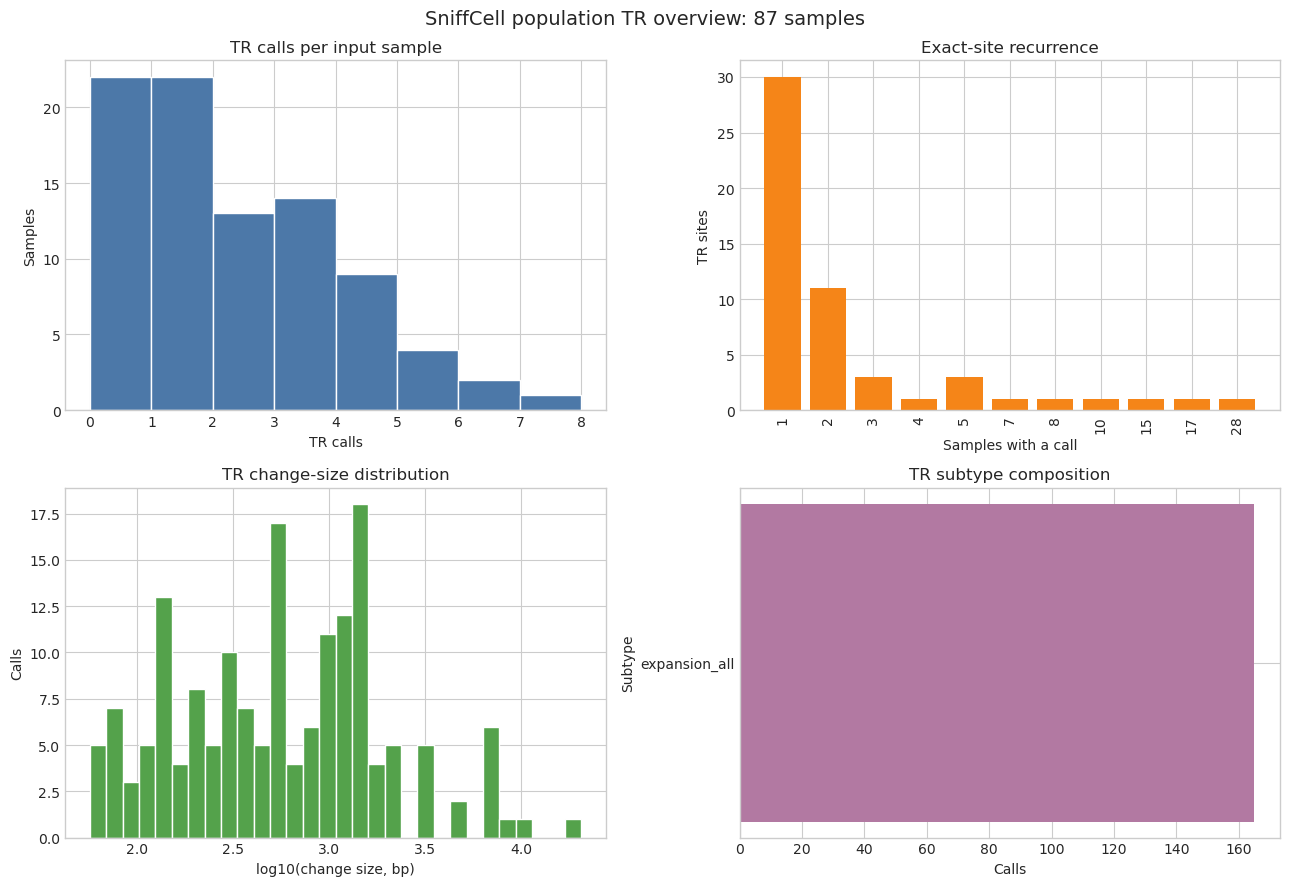

In [9]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].hist(per_sample_summary["n_tr_calls"], bins=range(0, int(per_sample_summary["n_tr_calls"].max()) + 2), color="#4C78A8", edgecolor="white")
axes[0, 0].set(title="TR calls per input sample", xlabel="TR calls", ylabel="Samples")

recurrence_counts = per_site_summary["n_samples"].value_counts().sort_index()
axes[0, 1].bar(recurrence_counts.index.astype(str), recurrence_counts.values, color="#F58518")
axes[0, 1].set(title="Exact-site recurrence", xlabel="Samples with a call", ylabel="TR sites")
axes[0, 1].tick_params(axis="x", rotation=90)

positive_sizes = tr_calls.loc[tr_calls["change_size_bp"] > 0, "change_size_bp"]
axes[1, 0].hist(np.log10(positive_sizes), bins=30, color="#54A24B", edgecolor="white")
axes[1, 0].set(title="TR change-size distribution", xlabel="log10(change size, bp)", ylabel="Calls")

subtype_plot = subtype_summary.head(15).sort_values("n_calls")
axes[1, 1].barh(subtype_plot["variant_subtype"].astype(str), subtype_plot["n_calls"], color="#B279A2")
axes[1, 1].set(title="TR subtype composition", xlabel="Calls", ylabel="Subtype")

fig.suptitle(f"SniffCell population TR overview: {n_samples} samples", fontsize=14)
fig.tight_layout()
plt.show()

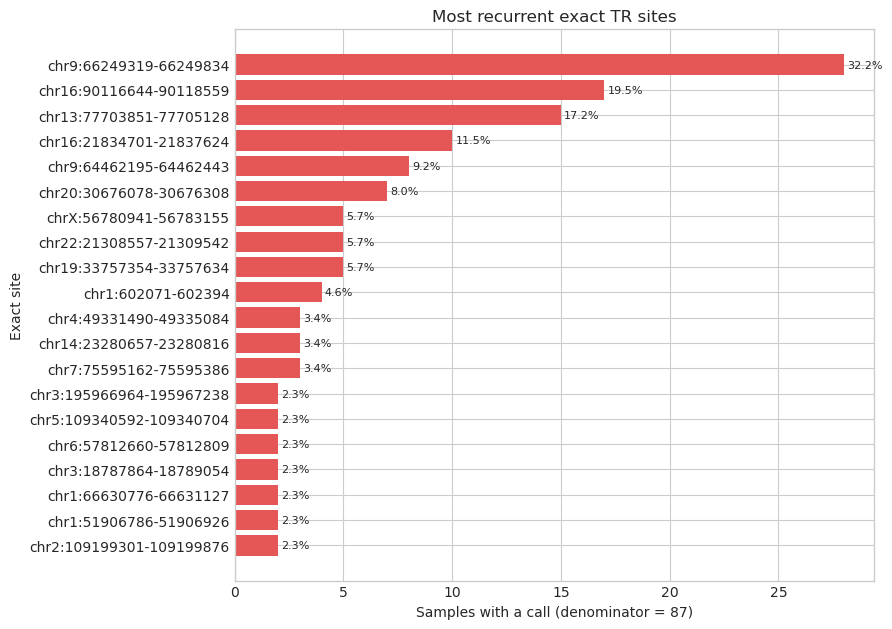

In [10]:
top_sites = per_site_summary.head(20).sort_values("n_samples")
fig, ax = plt.subplots(figsize=(9, max(5, 0.32 * len(top_sites))))
ax.barh(top_sites["site_key"], top_sites["n_samples"], color="#E45756")
ax.set(
    title="Most recurrent exact TR sites",
    xlabel=f"Samples with a call (denominator = {n_samples})",
    ylabel="Exact site",
)
for y, (_, row) in enumerate(top_sites.iterrows()):
    ax.text(row["n_samples"] + 0.15, y, f"{row['call_prevalence_pct']:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

### 8. Site-by-sample matrices

,check,left,right,status
0,manifest rows equal loaded variant rows,36388,36388,PASS
1,manifest TR rows equal loaded TR calls,165,165,PASS
2,subtype calls sum to all TR calls,165,165,PASS
3,category calls sum to all TR calls,165,165,PASS
4,presence matrix sums to sample-site pairs,165,165,PASS
5,per-sample table includes every loaded sample,87,87,PASS
6,per-site table includes every exact site,54,54,PASS


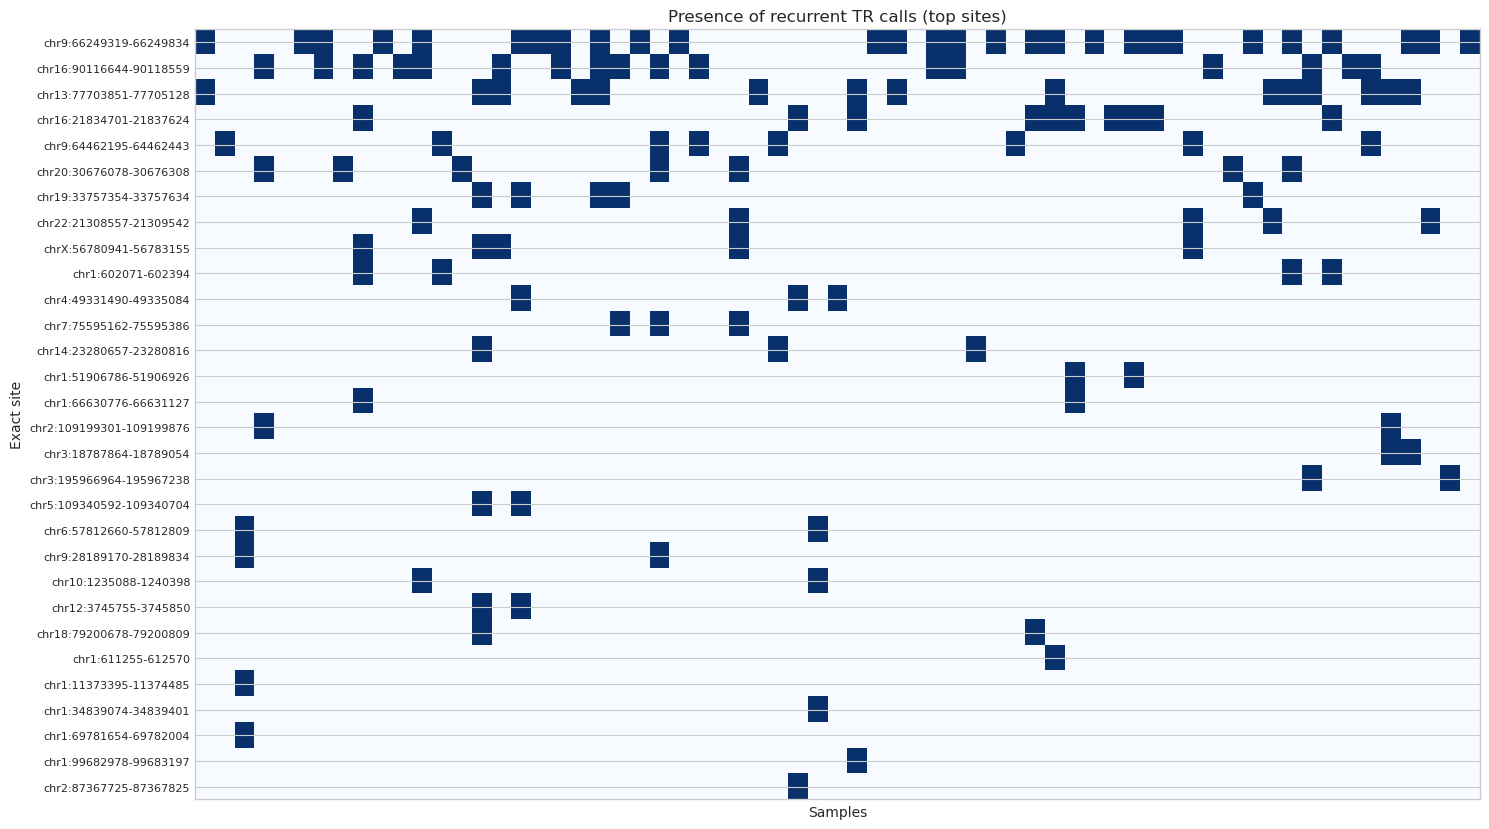

In [11]:
presence_matrix = (
    sample_site.assign(present=1)
    .pivot_table(index="site_key", columns="sample_id", values="present", aggfunc="max", fill_value=0)
    .astype(int)
)
change_size_matrix = sample_site.pivot_table(
    index="site_key", columns="sample_id", values="change_size_bp", aggfunc="median"
)

site_order = per_site_summary["site_key"].tolist()
presence_matrix = presence_matrix.reindex(site_order)
change_size_matrix = change_size_matrix.reindex(site_order)

reconciliation_checks = pd.DataFrame([
    {"check": "manifest rows equal loaded variant rows", "left": int(loaded_manifest["n_rows"].sum()), "right": len(all_variants)},
    {"check": "manifest TR rows equal loaded TR calls", "left": int(loaded_manifest["n_tr_rows"].sum()), "right": len(tr_calls)},
    {"check": "subtype calls sum to all TR calls", "left": int(subtype_summary["n_calls"].sum()), "right": len(tr_calls)},
    {"check": "category calls sum to all TR calls", "left": int(category_summary["n_calls"].sum()), "right": len(tr_calls)},
    {"check": "presence matrix sums to sample-site pairs", "left": int(presence_matrix.to_numpy().sum()), "right": len(sample_site)},
    {"check": "per-sample table includes every loaded sample", "left": len(per_sample_summary), "right": n_samples},
    {"check": "per-site table includes every exact site", "left": len(per_site_summary), "right": int(tr_calls["site_key"].nunique())},
])
reconciliation_checks["status"] = np.where(
    reconciliation_checks["left"].eq(reconciliation_checks["right"]), "PASS", "FAIL"
)
display(reconciliation_checks)
if reconciliation_checks["status"].eq("FAIL").any():
    raise AssertionError("A population-summary reconciliation check failed.")

top_matrix_sites = site_order[: min(30, len(site_order))]
fig, ax = plt.subplots(figsize=(15, max(5, 0.28 * len(top_matrix_sites))))
image = ax.imshow(presence_matrix.loc[top_matrix_sites], aspect="auto", interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
ax.set(title="Presence of recurrent TR calls (top sites)", xlabel="Samples", ylabel="Exact site")
ax.set_yticks(range(len(top_matrix_sites)), labels=top_matrix_sites, fontsize=8)
ax.set_xticks([])
plt.tight_layout()
plt.show()

### 9. Export reusable population tables

In [12]:
exports = {
    "headline_metrics.tsv": headline_metrics,
    "input_manifest.tsv": input_manifest,
    "data_quality_checks.tsv": quality_checks,
    "tr_calls_long.tsv": tr_calls,
    "per_sample_tr_summary.tsv": per_sample_summary,
    "per_site_tr_diversity.tsv": per_site_summary,
    "tr_subtype_summary.tsv": subtype_summary,
    "tr_category_summary.tsv": category_summary,
    "tr_change_size_summary.tsv": change_size_summary,
    "reconciliation_checks.tsv": reconciliation_checks,
    "site_by_sample_presence.tsv": presence_matrix.reset_index(),
    "site_by_sample_change_size_bp.tsv": change_size_matrix.reset_index(),
}

for filename, table in exports.items():
    table.to_csv(OUTPUT_DIR / filename, sep="\t", index=False)

print(f"Wrote {len(exports)} tables to {OUTPUT_DIR.resolve()}")
for filename in exports:
    print(" -", filename)

Wrote 12 tables to /stornext/snfs210/fritz/Yilei/SniffMeth/output/jupyter-notebook/population_tr_diversity_outputs
 - headline_metrics.tsv
 - input_manifest.tsv
 - data_quality_checks.tsv
 - tr_calls_long.tsv
 - per_sample_tr_summary.tsv
 - per_site_tr_diversity.tsv
 - tr_subtype_summary.tsv
 - tr_category_summary.tsv
 - tr_change_size_summary.tsv
 - reconciliation_checks.tsv
 - site_by_sample_presence.tsv
 - site_by_sample_change_size_bp.tsv


## Takeaways

- Use `headline_metrics` for the requested cohort-level numbers.
- Use `per_site_tr_diversity` to rank recurrent or change-size-diverse loci.
- Use `per_sample_tr_summary` to identify samples with unusually high differential-TR burden.
- Use the presence and change-size matrices for downstream clustering or association testing.
- For a formal population-genetics analysis, add a callable-locus denominator or genotype matrix. The harmonized call files alone cannot distinguish reference/no-change from no coverage or a failed comparison.

### Recommended next extensions

1. Join donor, tissue, sex, age, ancestry, platform, and batch metadata by `sample_id`.
2. Restrict comparisons to biologically comparable tissues/cell-group pairs.
3. Add locus-level callable status before estimating allele frequencies.
4. Cluster nearby non-identical intervals if runs did not use the same TR catalog.
5. Test recurrent loci against phenotype groups only after controlling for donor and technical covariates.